# ISDb — Excitingness Model

Trains on **World Cup** matches (IMDb episode rating = "excitingness" label) and
scores **Premier League** matches on the same scale.

**How to use this notebook**
- Edit the **Config** cell, then *Run All*. It fits the final model and writes
  `pl_excitingness.csv`, `model_coefficients.csv`, `excitingness_model.joblib`.
- Everything is driven by config: feature set, Ridge alpha, whether to drop
  extra-time matches, the "late" minute threshold, vote weighting.
- The **Optional experiments** at the bottom (model bake-off, Lasso/ElasticNet,
  forward selection, feature-count robustness) are the methods we explored but
  didn't ship. They're off by default — set `RUN_EXTRAS = True` to run them.

**Key modelling decisions baked in (see the experiments for evidence):**
- *Ridge, not boosting.* With ~139 labelled matches, XGBoost/LightGBM overfit
  and transfer worse. A regularised linear model wins on CV and on the
  leave-one-tournament-out transfer test.
- *Symmetric features.* Home/away is meaningless at neutral WC venues, so every
  home/away pair is collapsed to sum / abs-diff. This is what lets the model
  transfer to the Premier League.
- *Extra-time matches dropped.* The 75-90+ window and the "late" chasing
  features silently absorb minutes 91-120, which no PL match has. Dropping the
  8 ET matches keeps train and target on the same footing.
- *Curated feature set.* Adding features indiscriminately hurts Ridge on this
  little data; a forward-selected set of ~8 is the sweet spot.

## Config

In [1]:
from pathlib import Path

# --- paths ---------------------------------------------------------------
def _find_data():
    for p in ["data", "../data", "../../data", "isdb/data"]:
        if (Path(p) / "xg_timeline").exists():
            return Path(p)
    raise FileNotFoundError("Could not locate data/ — set DATA_DIR manually.")
DATA_DIR = _find_data()
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

# --- modelling knobs -----------------------------------------------------
EXCLUDE_EXTRA_TIME = True      # drop WC matches that went to ET (recommended)
LATE_MINUTE        = 75        # threshold for "late" chasing features
VOTE_WEIGHTED      = True      # weight training by IMDb vote count
RIDGE_ALPHA        = 30.0      # L2 strength (or set to "cv" to tune each fit)
BIG_XG_THRESH      = 0.30      # a shot with xG >= this counts as a "big chance"
CV_FOLDS           = 5
SEED               = 0

# Final feature set (forward-selected on the ET-free data).
# Set FEATURE_SET = None to use ALL engineered features instead.
FEATURE_SET = [
    "total_goals", "goal_diff_abs", "xg_absdiff_30-45", "xg_absdiff_0-15",
    "big_chances_60-75", "chasing_xg", "final5_swing_count", "xg_absdiff_75-90plus",
    # team strength / David-vs-Goliath — the single biggest win in this project
    "avg_strength", "gap_strength", "upset",
]

RUN_EXTRAS = False             # True -> run the optional experiment cells
print("DATA_DIR =", DATA_DIR.resolve())

DATA_DIR = /home/claude/nbtest/data


## Imports

In [2]:
import json, glob, warnings
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.base import clone
from scipy.stats import spearmanr
import joblib
warnings.filterwarnings("ignore")
rng = np.random.RandomState(SEED)

## Feature engineering

Symmetric features only. Each home/away pair becomes `sum` (how much happened)
and `absdiff` (how lopsided). Inherently symmetric quantities pass through.
Tweak `make_features` freely — everything downstream uses it.

In [3]:
WINDOWS = ["0-15", "15-30", "30-45", "45-60", "60-75", "75-90plus"]

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.DataFrame(index=df.index)
    # goals (symmetric)
    f["total_goals"]   = df.home_score + df.away_score
    f["goal_diff_abs"] = (df.home_score - df.away_score).abs()
    # volume / quality (already symmetric)
    f["total_shots"]      = df.total_shots
    f["total_xg"]         = df.total_xg
    f["xg_per_shot"]      = df.total_xg / df.total_shots.replace(0, np.nan)
    f["largest_xg_swing"] = df.largest_xg_swing
    f["xg_lead_changes"]  = df.xg_lead_changes
    # per-window xG as sum / absdiff
    for wdw in WINDOWS:
        h, a = df[f"xg_home_{wdw}"], df[f"xg_away_{wdw}"]
        f[f"xg_sum_{wdw}"]     = h + a
        f[f"xg_absdiff_{wdw}"] = (h - a).abs()
    # opening & closing intensity
    f["late_xg_sum"]  = f["xg_sum_60-75"] + f["xg_sum_75-90plus"]
    f["early_xg_sum"] = f["xg_sum_0-15"] + f["xg_sum_15-30"]
    f["xg_balance"]   = 1 - (df[[f"xg_diff_{w}" for w in WINDOWS]].abs().sum(axis=1)
                             / (df[[f"xg_home_{w}" for w in WINDOWS]].sum(axis=1)
                                + df[[f"xg_away_{w}" for w in WINDOWS]].sum(axis=1)).replace(0, np.nan))
    return f.fillna(0.0)

# NOTE: xg_first_15 / xg_last_15 in the raw CSV duplicate the 0-15 / 75-90plus
# windows, so we deliberately do NOT build separate features from them.

## Chasing (trailing-team) features

Reconstruct the score at each shot and sum the *behind* team's xG and goals —
especially late. Captures comeback pressure, which is about score **state**, not
goal count. Team-agnostic, so symmetric by construction.

`final5_swing_count` counts lead changes (level or flip allowed) in the final
5 minutes plus all stoppage time — a "true minute" that adds WC's `added_time`
to `time_minute` (PL's `minute` is already continuous past 90). This replaced
an earlier boolean `late_result_swing` (>= 75') after a 30-seed stability test
showed the finer, count-based final-5-plus-stoppage window is a real,
reproducible improvement (28/30 seeds, CV RMSE -0.005, bigger than the seed
noise) — unlike most feature additions tried in this project.

In [4]:
def _wc_shots(raw):
    return [{"min": (s.get("time_minute") or 0), "sec": (s.get("time_seconds") or 0),
             "added": (s.get("added_time") or 0),
             "team": "H" if s.get("is_home") else "A", "xg": s.get("xg") or 0.0,
             "goal": s.get("shot_type") == "goal", "own": s.get("goal_type") == "own"}
            for s in raw["shots"]]

def _pl_shots(raw):
    out = []
    for side, shots in (("H", raw["shots_h"]), ("A", raw["shots_a"])):
        for s in shots:
            r = s.get("result")
            out.append({"min": int(float(s.get("minute") or 0)), "sec": 0, "added": 0, "team": side,
                        "xg": float(s.get("xG") or 0.0), "goal": r in ("Goal", "OwnGoal"),
                        "own": r == "OwnGoal"})
    return out

def chasing_features(shots, late=None):
    late = LATE_MINUTE if late is None else late
    shots = sorted(shots, key=lambda s: (s["min"], s["sec"]))
    gH = gA = 0
    chase_xg = chase_xg_late = 0.0; chase_goals_late = 0
    late_swing_count = 0; final5_swing_count = 0
    for s in shots:
        sg, og = (gH, gA) if s["team"] == "H" else (gA, gH)
        trailing = sg < og
        if trailing:
            chase_xg += s["xg"]
            if s["min"] >= late: chase_xg_late += s["xg"]
        if s["goal"]:
            scoring = ("A" if s["team"] == "H" else "H") if s["own"] else s["team"]
            lead_b = (gH > gA) - (gH < gA)
            if scoring == "H": gH += 1
            else:              gA += 1
            lead_a = (gH > gA) - (gH < gA)
            true_min = s["min"] + s.get("added", 0)
            if s["min"] >= late:
                if trailing and not s["own"]: chase_goals_late += 1
                if lead_a != lead_b:          late_swing_count += 1
            if true_min >= 85 and lead_a != lead_b:
                final5_swing_count += 1
    return {"chasing_xg": round(chase_xg, 4), "chasing_xg_late": round(chase_xg_late, 4),
            "chasing_goals_late": chase_goals_late, "late_swing_count": late_swing_count,
            "final5_swing_count": final5_swing_count}

def wc_chasing(mid, season):
    p = DATA_DIR / f"xg_timeline/wc/wc{season}_match_{mid}.json"
    return chasing_features(_wc_shots(json.load(open(p))))

def pl_chasing(mid):
    hits = glob.glob(str(DATA_DIR / f"xg_timeline/pl/pl*_match_{mid}.json"))
    return chasing_features(_pl_shots(json.load(open(hits[0]))))

## Load data

`wc_labelled.csv` (WC features joined to IMDb ratings) is built here if it's
missing. It only needs `wc_features.csv` + the IMDb JSON, both already in the
repo. `wc_features.csv` itself is rebuilt from cached shot JSON (no network) if
absent. The IMDb name->code matcher is reused from `pipeline/`. Extra-time
matches are dropped after loading.

In [5]:
import subprocess, sys

def _find_dir(names):
    for p in names:
        if Path(p).exists():
            return Path(p)
    return None
PIPELINE_DIR = _find_dir(["pipeline", "../pipeline", "../../pipeline", "isdb/pipeline"])

wc_feat  = DATA_DIR / "xg_timeline/wc/wc_features.csv"
lab_path = DATA_DIR / "xg_timeline/wc/wc_labelled.csv"

# (1) build wc_features.csv from cached shot JSON if missing (no network / no key)
if not wc_feat.exists():
    assert PIPELINE_DIR, f"{wc_feat} missing and pipeline/ not found to rebuild it"
    print("wc_features.csv missing -> rebuilding from cached shots ...")
    subprocess.run([sys.executable, "wc_xg_timeline_fetch.py", "--features-only"],
                   cwd=str(PIPELINE_DIR), check=True)

# (2) build wc_labelled.csv by joining features to IMDb ratings if missing
if not lab_path.exists():
    assert PIPELINE_DIR, f"{lab_path} missing and pipeline/ not found to build it"
    sys.path.insert(0, str(PIPELINE_DIR))
    from match_stats_fetch import title_to_codes         # reuse the repo's matcher
    ALIAS = {"CAM": "CMR"}                                # BallDontLie -> IMDb code
    TITLE_FIX = {"Cura\u00e7ao": "CUW"}                   # accent-stripping edge case
    def _codes(title):
        cs = title_to_codes(title)
        for name, code in TITLE_FIX.items():
            if name in title and code not in cs:
                cs.append(code)
        return cs
    pair2 = {}
    for fn, yr in [("wc2022.json", 2022), ("wc2026.json", 2026)]:
        for ep in json.load(open(DATA_DIR / "imdb" / fn))["episodes"]:
            cs = _codes(ep.get("title", ""))
            if len(cs) == 2:
                pair2[(yr, frozenset(cs))] = (ep.get("rating"), ep.get("votes"))
    canon = lambda code: ALIAS.get(code, code)
    wc = pd.read_csv(wc_feat)
    rr, vv = [], []
    for _, r in wc.iterrows():
        key = (int(r.season_year), frozenset([canon(r.home), canon(r.away)]))
        rating, votes = pair2.get(key, (np.nan, np.nan))
        rr.append(rating); vv.append(votes)
    wc["imdb_rating"], wc["imdb_votes"] = rr, vv
    matched = wc.imdb_rating.notna().sum()
    wc = wc.dropna(subset=["imdb_rating"])
    wc.to_csv(lab_path, index=False)
    print(f"built wc_labelled.csv: {matched} matches matched to a rating")

lab_all = pd.read_csv(lab_path)

if EXCLUDE_EXTRA_TIME and "extra_time" in lab_all.columns:
    lab = lab_all[~lab_all.extra_time].reset_index(drop=True)
    print(f"training rows: {len(lab_all)} -> {len(lab)} "
          f"(dropped {int(lab_all.extra_time.sum())} extra-time matches)")
else:
    lab = lab_all.reset_index(drop=True)
    print(f"training rows: {len(lab)}")

pl = pd.read_csv(DATA_DIR / "xg_timeline/pl/pl_features.csv")
print("PL matches to score:", len(pl))

built wc_labelled.csv: 168 matches matched to a rating
training rows: 168 -> 154 (dropped 14 extra-time matches)
PL matches to score: 400


## World Cup red-card features (trainable, but NOT in the default set)

Unlike the PL cards below, this list — from Wikipedia's "List of FIFA World
Cup red cards" — covers **both** WC2022 and WC2026, so it can actually be fed
into the trained model (Ridge needs the feature on both the training and
prediction side to learn from it).

**A 30-seed stability test says don't use it by default.** `red_card_by_leading
_team` is directionally sensible (a card against the team that's ahead
correlates +0.10 with excitement) but only beats the base model in 17/30 CV
seeds — a coin flip, and no candidate red-card feature clears that bar. The
reason isn't that red cards don't matter for excitement; it's that a World Cup
only produces ~15-20 total, so out of 154 non-ET training matches only ~16 have
one at all. There's no honest way to fit a reliable coefficient on that few
events. Add `red_card_by_leading_team` (or another column below) to
`FEATURE_SET` if you want to use it anyway, or if training data grows (more
tournaments, or a switch to training on league seasons) enough to make the
signal estimable.

In [6]:
# date | player | country_code | opponent_code | true_minute (added_time incl.)
# source: Wikipedia "List of FIFA World Cup red cards". Team-official cards
# (don't reduce players on the pitch) are excluded.
WC_RED_RAW = """2022-11-25|Wayne Hennessey|WAL|IRN|86
2022-12-02|Vincent Aboubakar|CAM|BRA|93
2022-12-09|Denzel Dumfries|NED|ARG|128
2022-12-10|Walid Cheddira|MAR|POR|93
2026-06-11|Sphephelo Sithole|RSA|MEX|49
2026-06-11|Themba Zwane|RSA|MEX|84
2026-06-11|Cesar Montes|MEX|RSA|92
2026-06-18|Tarik Muharemovic|BIH|SUI|80
2026-06-18|Homam Ahmed|QAT|CAN|33
2026-06-18|Assim Madibo|QAT|CAN|55
2026-06-19|Miguel Almiron|PAR|TUR|48
2026-06-21|Nathan Ngoy|BEL|IRN|66
2026-06-26|Rebin Sulaka|IRQ|SEN|13
2026-06-26|Agustin Canobbio|URU|ESP|95
2026-06-30|Piero Hincapie|ECU|MEX|95
2026-07-01|Folarin Balogun|USA|BIH|64
2026-07-05|Jarell Quansah|ENG|MEX|54
2026-07-11|Breel Embolo|SUI|ARG|72
2026-07-19|Enzo Fernandez|ARG|ESP|93"""

WLAB_RC = ["0-15","15-30","30-45","45-60","60-75","75-90plus"]
def _widx_rc(m):
    for i,(a,b) in enumerate([(0,15),(15,30),(30,45),(45,60),(60,75),(75,10**9)]):
        if a <= m < b: return i
    return 5

def _wc_leading_at(mid, season, team_code, home_code, minute):
    shots = _wc_shots(json.load(open(DATA_DIR / f"xg_timeline/wc/wc{season}_match_{mid}.json")))
    gh = ga = 0
    for s in shots:
        tm = s["min"] + s.get("added", 0)
        if s["goal"] and tm < minute:
            scoring = ("A" if s["team"] == "H" else "H") if s["own"] else s["team"]
            if scoring == "H": gh += 1
            else: ga += 1
    red_home = (team_code == home_code)
    rs, os_ = (gh, ga) if red_home else (ga, gh)
    return rs, os_

def build_wc_red_card_features(lab_df):
    rows = []
    for line in WC_RED_RAW.strip().split("\n"):
        date_s, player, team, opp, true_min = line.split("|")
        rows.append({"date": date_s, "team": team, "opp": opp, "true_minute": int(true_min),
                    "season": 2022 if date_s < "2023-01-01" else 2026,
                    "pair": frozenset([team, opp])})
    rc = pd.DataFrame(rows)
    lab_pairs = lab_df.assign(pair=lab_df.apply(lambda r: frozenset([r.home, r.away]), axis=1))

    joined = []
    for _, r in rc.iterrows():
        cand = lab_pairs[(lab_pairs.season_year == r.season) & (lab_pairs.pair == r.pair)]
        if len(cand): joined.append({**r.to_dict(), "match_id": cand.iloc[0].match_id, "home": cand.iloc[0].home})
    jdf = pd.DataFrame(joined)

    feat_rows = []
    for mid, group in jdf.groupby("match_id"):
        season = int(group.season.iloc[0]); home_code = group.home.iloc[0]
        per_window = [0] * 6; leading = []
        for _, rr in group.iterrows():
            per_window[_widx_rc(min(rr.true_minute, 89))] += 1
            rs, os_ = _wc_leading_at(mid, season, rr.team, home_code, rr.true_minute)
            leading.append(1 if rs > os_ else 0)
        d = {"match_id": mid, "red_cards_total": len(group),
             "red_card_by_leading_team": sum(leading),
             "red_cards_final5_stoppage": int((group.true_minute >= 85).sum())}
        for i, lb in enumerate(WLAB_RC): d[f"red_cards_{lb}"] = per_window[i]
        feat_rows.append(d)
    out = pd.DataFrame(feat_rows)
    merged = lab_df[["match_id"]].merge(out, on="match_id", how="left")
    return merged.drop(columns=["match_id"]).fillna(0).astype(int)

wc_redcards = build_wc_red_card_features(lab)
print(f"WC matches with >=1 red card: {(wc_redcards.red_cards_total > 0).sum()} / {len(lab)}")

WC matches with >=1 red card: 13 / 154


## Big-chance & goals-minus-xG features (per period)

Two families derived from raw shots, at match level **and** for each 15-min
window: **big chances** (shots with xG >= `BIG_XG_THRESH`) and **goals - xG**
(finishing delta: positive = scored more than expected). Team-agnostic, so they
transfer WC->PL. The 60-75' big-chance count is in the default feature set.

In [7]:
_WIN  = [(0,15),(15,30),(30,45),(45,60),(60,75),(75,200)]
_WLAB = ["0-15","15-30","30-45","45-60","60-75","75-90plus"]
def _widx(m):
    for i,(a,b) in enumerate(_WIN):
        if a <= m < b: return i
    return len(_WIN)-1

def period_features(shots, big=None):
    big = BIG_XG_THRESH if big is None else big
    bc=[0]*6; gl=[0]*6; xg=[0.0]*6; bc_h=bc_a=0
    for s in shots:
        i=_widx(s["min"]); xg[i]+=s["xg"]
        if s["xg"] >= big:
            bc[i]+=1
            if s["team"]=="H": bc_h+=1
            else: bc_a+=1
        if s["goal"]: gl[i]+=1
    f = {"big_chances": sum(bc), "big_chances_absdiff": abs(bc_h-bc_a),
         "goals_minus_xg": sum(gl)-sum(xg)}
    for i, lab in enumerate(_WLAB):
        f[f"big_chances_{lab}"]    = bc[i]
        f[f"goals_minus_xg_{lab}"] = gl[i] - xg[i]
    return f

def wc_period(mid, season):
    return period_features(_wc_shots(json.load(open(
        DATA_DIR / f"xg_timeline/wc/wc{season}_match_{mid}.json"))))
def pl_period(mid):
    return period_features(_pl_shots(json.load(open(
        glob.glob(str(DATA_DIR / f"xg_timeline/pl/pl*_match_{mid}.json"))[0]))))

## Lead-change features (by quarter)

Times the **lead changed hands** — on goals and on cumulative xG — tallied into
the four 22.5-min quarters. A lead change is tracked with the last team to hold
a lead, so it correctly counts goal turnarounds that pass through a level score
(1-0 -> 1-1 -> 1-2 is one change).

Note: these are **not in the default feature set**. `goal_lead_changes`
correlates well with excitement (+0.32) but a stability test across CV seeds
shows it doesn't robustly improve prediction (it's collinear with total goals /
late swings). They're computed here so you can select them or use them as
descriptive columns. `goal_lead_changes_q1` is omitted (a lead can't change in
the first quarter).

In [8]:
_QB = [0, 22.5, 45, 67.5, float("inf")]
def _quarter(m):
    for i in range(4):
        if _QB[i] <= m < _QB[i+1]: return i
    return 3

def _lead_changes(shots, mode):
    shots = sorted(shots, key=lambda s: (s["min"], s["sec"]))
    ch = cw = 0.0; last = None; out = [0, 0, 0, 0]
    for s in shots:
        if mode == "xg":
            ch += s["xg"] if s["team"] == "H" else 0
            cw += s["xg"] if s["team"] == "A" else 0
        else:
            if not s["goal"]: continue
            scoring = ("A" if s["team"] == "H" else "H") if s["own"] else s["team"]
            ch += 1 if scoring == "H" else 0
            cw += 1 if scoring == "A" else 0
        leader = "H" if ch > cw else ("A" if cw > ch else "L")
        if leader != "L":
            if last is not None and leader != last:
                out[_quarter(s["min"])] += 1
            last = leader
    return out

def leadchange_features(shots):
    xg = _lead_changes(shots, "xg"); gl = _lead_changes(shots, "goal")
    f = {"goal_lead_changes": sum(gl)}
    for i in range(4):
        f[f"xg_lead_changes_q{i+1}"] = xg[i]
    for i in (1, 2, 3):                       # q1 goal lead change is always 0
        f[f"goal_lead_changes_q{i+1}"] = gl[i]
    return f

def wc_leadchg(mid, season):
    return leadchange_features(_wc_shots(json.load(open(
        DATA_DIR / f"xg_timeline/wc/wc{season}_match_{mid}.json"))))
def pl_leadchg(mid):
    return leadchange_features(_pl_shots(json.load(open(
        glob.glob(str(DATA_DIR / f"xg_timeline/pl/pl*_match_{mid}.json"))[0]))))

## Red-card features (Premier League only — descriptive, not trained)

Red cards, penalties, and fouls need Sofascore's `match_stats` (cards/fouls/
goal-minutes), which this pipeline can fetch (`pipeline/match_stats_fetch.py`)
but which hasn't been run for the World Cup side of the data. **Ridge needs a
feature on both the training (WC) and prediction (PL) side to learn a
coefficient from it** — a PL-only column can't enter the trained model, so
these are computed as **descriptive columns only**, appended to
`pl_excitingness.csv` after prediction. They do not affect `excitingness`.

The red-card list below is manually curated (paste your own to update it).
Player -> team mapping is best-effort; verify before treating it as ground
truth. Once `match_stats_fetch.py` has been run for the World Cup, these same
functions become trainable — pull the equivalent WC red-card list into
`chasing_features`-style shot dicts and add e.g. `red_cards_final5_stoppage` to
`FEATURE_SET`.

In [9]:
import re

TEAM2CODE = {
 "Aston Villa":"AVL","Newcastle United":"NEW","Bournemouth":"BOU","Wolves":"WOL",
 "Liverpool":"LIV","West Ham":"WHU","West Ham United":"WHU","Tottenham":"TOT",
 "Burnley":"BUR","Manchester United":"MUN","Chelsea":"CHE","Sunderland":"SUN",
 "Brighton":"BRI","Nottingham Forest":"NOT","Fulham":"FLH","Brentford":"BRE",
 "Everton":"EVE","Crystal Palace":"CRY","Arsenal":"ARS","Leeds United":"LED",
 "Manchester City":"MCI",
}
# player -> team, best-effort (verify before relying on this for anything critical)
PLAYER_TEAM = {
 "Ezri Konsa":"AVL","Toti Gomes":"WOL","Anthony Gordon":"NEW","Tomas Soucek":"WHU",
 "Lesley Ugochukwu":"BUR","Robert Sanchez":"MUN","Casemiro":"MUN","Reinildo Mandava":"SUN",
 "Trevoh Chalobah":"CHE","Malo Gusto":"CHE","Emmanuel Agbadou":"WOL","Dan Burn":"NEW",
 "Idrissa Gueye":"EVE","Lewis Cook":"BOU","Lucas Paqueta":"WHU","Moises Caicedo":"CHE",
 "Luke O'Nien":"SUN","Lucas Pires":"BUR","Xavi Simons":"TOT","Cristian Romero":"TOT",
 "Michael Keane":"EVE","Jack Grealish":"EVE","Marc Cucurella":"CHE","Adam Wharton":"CRY",
 "Jean-Clair Todibo":"WHU","Kevin Schade":"BRE","Neco Williams":"NOT",
 "Cristian Romero (2nd)":"TOT","Dominik Szoboszlai":"LIV","Jake O'Brien":"EVE",
 "Wesley Fofana":"CHE","Ladislav Krejci":"WOL","Maxence Lacroix":"CRY","Pedro Neto":"CHE",
 "Jacob Ramsey":"NEW","Micky van de Ven":"TOT","Gabriel Gudmundsson":"LED",
 "Harry Maguire":"MUN","Josh Laurent":"BUR","Lisandro Martinez":"MUN","Daniel Ballard":"SUN",
 "Ryan Christie":"BOU","Joachim Andersen":"FLH","Wesley Fofana (2nd)":"CHE",
}
RED_CARDS_RAW = """Aug 16, 2025 | Ezri Konsa | Aston Villa v Newcastle United | 66'
Aug 23, 2025 | Toti Gomes | Bournemouth v Wolves | 49'
Aug 25, 2025 | Anthony Gordon | Newcastle United v Liverpool | 45+3'
Sep 13, 2025 | Tomas Soucek | West Ham v Tottenham | 54'
Sep 14, 2025 | Lesley Ugochukwu | Burnley v Liverpool | 84'
Sep 20, 2025 | Robert Sanchez | Manchester United v Chelsea | 5'
Sep 20, 2025 | Casemiro | Manchester United v Chelsea | 45+5'
Sep 21, 2025 | Reinildo Mandava | Sunderland v Aston Villa | 33'
Sep 27, 2025 | Trevoh Chalobah | Chelsea v Brighton | 53'
Oct 18, 2025 | Malo Gusto | Nottingham Forest v Chelsea | 87'
Nov 1, 2025 | Emmanuel Agbadou | Fulham v Wolves | 36'
Nov 9, 2025 | Dan Burn | Brentford v Newcastle United | 73'
Nov 24, 2025 | Idrissa Gueye | Manchester United v Everton | 13'
Nov 29, 2025 | Lewis Cook | Sunderland v Bournemouth | 90+6'
Nov 30, 2025 | Lucas Paqueta | West Ham United v Liverpool | 84'
Nov 30, 2025 | Moises Caicedo | Chelsea v Arsenal | 38'
Dec 6, 2025 | Luke O'Nien | Manchester City v Sunderland | 90+5'
Dec 6, 2025 | Lucas Pires | Newcastle United v Burnley | 43'
Dec 20, 2025 | Xavi Simons | Tottenham v Liverpool | 33'
Dec 20, 2025 | Cristian Romero | Tottenham v Liverpool | 90+3'
Jan 7, 2026 | Michael Keane | Everton v Wolves | 83'
Jan 7, 2026 | Jack Grealish | Everton v Wolves | 90'
Jan 7, 2026 | Marc Cucurella | Fulham v Chelsea | 22'
Jan 25, 2026 | Adam Wharton | Crystal Palace v Chelsea | 72'
Jan 31, 2026 | Jean-Clair Todibo | Chelsea v West Ham | 90+11'
Feb 1, 2026 | Kevin Schade | Aston Villa v Brentford | 42'
Feb 1, 2026 | Neco Williams | Nottingham Forest v Crystal Palace | 45'
Feb 7, 2026 | Cristian Romero (2nd) | Manchester United v Tottenham | 29'
Feb 8, 2026 | Dominik Szoboszlai | Liverpool v Manchester City | 90+13'
Feb 10, 2026 | Jake O'Brien | Everton v Bournemouth | 69'
Feb 21, 2026 | Wesley Fofana | Chelsea v Burnley | 72'
Feb 22, 2026 | Ladislav Krejci | Crystal Palace v Wolves | 61'
Mar 1, 2026 | Maxence Lacroix | Manchester United v Crystal Palace | 56'
Mar 1, 2026 | Pedro Neto | Arsenal v Chelsea | 70'
Mar 4, 2026 | Jacob Ramsey | Newcastle United v Manchester United | 45+1'
Mar 5, 2026 | Micky van de Ven | Tottenham v Crystal Palace | 38'
Mar 15, 2026 | Gabriel Gudmundsson | Crystal Palace v Leeds United | 45+5'
Mar 20, 2026 | Harry Maguire | Bournemouth v Manchester United | 78'
Mar 21, 2026 | Josh Laurent | Fulham v Burnley | 90+3'
Apr 13, 2026 | Lisandro Martinez | Manchester United v Leeds United | 56'
May 2, 2026 | Daniel Ballard | Wolves v Sunderland | 24'
May 9, 2026 | Ryan Christie | Fulham v Bournemouth | 41'
May 9, 2026 | Joachim Andersen | Fulham v Bournemouth | 45+7'
May 24, 2026 | Wesley Fofana (2nd) | Sunderland v Chelsea | 62'"""

WLAB6 = ["0-15","15-30","30-45","45-60","60-75","75-90plus"]
def _widx6(m):
    for i,(a,b) in enumerate([(0,15),(15,30),(30,45),(45,60),(60,75),(75,10**9)]):
        if a <= m < b: return i
    return 5

def _rc_leading_at(mid, home_code, minute):
    hits = glob.glob(str(DATA_DIR / f"xg_timeline/pl/pl*_match_{mid}.json"))
    if not hits: return None, None
    shots = _pl_shots(json.load(open(hits[0])))
    gh = ga = 0
    for s in shots:
        if s["goal"] and s["min"] < minute:
            scoring = ("A" if s["team"] == "H" else "H") if s["own"] else s["team"]
            if scoring == "H": gh += 1
            else: ga += 1
    return gh, ga

def build_pl_red_card_features(pl_df):
    rows = []
    for line in RED_CARDS_RAW.strip().split("\n"):
        date_s, player, match, minute_s = [x.strip() for x in line.split("|")]
        home_s, away_s = [x.strip() for x in match.split(" v ")]
        home, away = TEAM2CODE[home_s], TEAM2CODE[away_s]
        m = re.match(r"(\d+)\+?(\d+)?", minute_s)
        true_min = int(m.group(1)) + int(m.group(2) or 0)
        team = PLAYER_TEAM.get(player, "?")
        rows.append({"date": pd.to_datetime(date_s).strftime("%Y-%m-%d"), "player": player,
                    "home": home, "away": away, "true_minute": true_min, "red_team": team})
    rc = pd.DataFrame(rows)
    rc["pair"] = rc.apply(lambda r: frozenset([r.home, r.away]), axis=1)
    pl_df = pl_df.copy()
    pl_df["pair"] = pl_df.apply(lambda r: frozenset([r.home, r.away]), axis=1)
    pl_df["date_only"] = pd.to_datetime(pl_df.date).dt.strftime("%Y-%m-%d")

    joined = []
    for _, r in rc.iterrows():
        cand = pl_df[(pl_df.pair == r.pair) & (pl_df.date_only == r.date)]
        if len(cand) == 0:
            cand = pl_df[pl_df.pair == r.pair]
        if len(cand) == 0:
            continue
        joined.append({**r.to_dict(), "match_id": cand.iloc[0].match_id})
    jdf = pd.DataFrame(joined)

    feat_rows = []
    for mid, group in jdf.groupby("match_id"):
        row = pl_df[pl_df.match_id == mid].iloc[0]
        per_window = [0] * 6; leading = []
        for _, rr in group.iterrows():
            per_window[_widx6(min(rr.true_minute, 89))] += 1
            gh, ga = _rc_leading_at(mid, row.home, rr.true_minute)
            red_home = (rr.red_team == row.home)
            rs, os_ = (gh, ga) if red_home else (ga, gh)
            leading.append(1 if (rs is not None and rs > os_) else 0)
        d = {"match_id": mid, "red_cards_total": len(group),
             "red_card_by_leading_team": sum(leading),
             "red_cards_final5_stoppage": int((group.true_minute >= 85).sum())}
        for i, lb in enumerate(WLAB6):
            d[f"red_cards_{lb}"] = per_window[i]
        feat_rows.append(d)
    return pd.DataFrame(feat_rows)

pl_redcards_sparse = build_pl_red_card_features(pl)   # only matches with a card
print(f"Red cards found in {len(pl_redcards_sparse)} of {len(pl)} PL matches "
      f"({pl_redcards_sparse.red_cards_total.sum()} total)")
pl_redcards = (pl[["match_id"]].merge(pl_redcards_sparse, on="match_id", how="left")
               .drop(columns=["match_id"]).fillna(0).astype(int))  # row-aligned with `pl`, zero-filled

Red cards found in 40 of 400 PL matches (44 total)


## Team-strength / David-vs-Goliath features

The strongest signal found in this project. Residual analysis showed the model
was blind to *who was playing*: upsets (Argentina 1-2 Saudi Arabia) were badly
under-predicted, while goal-heavy games between teams nobody follows were
over-predicted. These three features fix that, and cut the model's correlation
with raw goal count from ~0.82 to ~0.68.

Strength comes from **FIFA world ranking** (WC, pre-tournament) and **preseason
expected finish** (PL). The two live on different scales (1-86 vs 1-20), so both
are converted to a within-competition percentile before use — that's what lets
the feature transfer from the World Cup to the Premier League.

Rankings are hand-entered below. WC2022 (Oct 2022 FIFA) and the 2025/26 PL
(Opta preseason) are reliable; a few lower-ranked WC2026 sides and the 2026/27
PL order are approximate. Swapping in a proper Elo feed would make this
reproducible and self-updating.

In [10]:
from scipy.stats import rankdata as _rd

FIFA_RANK_2022 = {"BRA":1,"BEL":2,"ARG":3,"FRA":4,"ENG":5,"ESP":7,"NED":8,"POR":9,"DEN":10,"GER":11,
 "CRO":12,"MEX":13,"URU":14,"SUI":15,"USA":16,"SEN":18,"WAL":19,"IRN":20,"SRB":21,"MAR":22,"JPN":24,
 "POL":26,"KOR":28,"TUN":30,"CRC":31,"AUS":38,"CAN":41,"CAM":43,"ECU":44,"QAT":50,"KSA":51,"GHA":61}
FIFA_RANK_2026 = {"ARG":1,"ESP":2,"FRA":3,"ENG":4,"BRA":5,"POR":6,"NED":7,"BEL":8,"CRO":9,"GER":10,
 "MAR":11,"MEX":13,"COL":14,"URU":15,"SUI":16,"USA":17,"IRN":18,"JPN":19,"SEN":20,"KOR":23,"AUT":24,
 "ECU":25,"TUR":26,"AUS":27,"ALG":28,"NOR":29,"PAN":30,"CAN":30,"SWE":31,"EGY":34,"SCO":36,"PAR":39,
 "TUN":40,"CZE":41,"CIV":42,"UZB":50,"QAT":51,"COD":57,"IRQ":58,"KSA":60,"RSA":61,"JOR":63,"CPV":68,
 "GHA":72,"BIH":74,"CUW":82,"HAI":84,"NZL":86}
PL_EXPECTED_2025 = {"LIV":1,"ARS":2,"MCI":3,"CHE":4,"AVL":5,"NEW":6,"CRY":7,"BRI":8,"BOU":9,"BRE":10,
 "NOT":11,"MUN":12,"EVE":13,"TOT":14,"FLH":15,"WHU":16,"WOL":17,"BUR":18,"LED":19,"SUN":20}
PL_EXPECTED_2026 = {"ARS":1,"MCI":2,"LIV":3,"CHE":4,"AVL":5,"NEW":6,"MUN":7,"BRI":8,"BRE":9,"TOT":10,
 "EVE":11,"BOU":12,"CRY":13,"NOT":14,"LED":15,"HUL":16,"SUN":17,"IPS":18,"COV":19,"FLH":20}

def _pct_map(rank_dict):
    codes=list(rank_dict); pos=np.array([rank_dict[c] for c in codes])
    return dict(zip(codes, _rd(pos, method="average")/len(codes)))   # 0..1, low = stronger
WC_PCT = {2022:_pct_map(FIFA_RANK_2022), 2026:_pct_map(FIFA_RANK_2026)}
PL_PCT = {2025:_pct_map(PL_EXPECTED_2025), 2026:_pct_map(PL_EXPECTED_2026)}

def strength_features(row, pct_maps):
    m = pct_maps.get(int(row.season_year), {})
    ph, pa = m.get(row.home, 0.6), m.get(row.away, 0.6)
    fav, dog = min(ph, pa), max(ph, pa)
    gap = dog - fav
    if row.home_score == row.away_score:
        dog_result = 0.5
    else:
        home_won = row.home_score > row.away_score
        fav_is_home = ph <= pa
        dog_result = 0.0 if (home_won == fav_is_home) else 1.0
    return {"avg_strength": (ph+pa)/2,   # match quality (lower = bigger match)
            "gap_strength": gap,          # mismatch size
            "upset": gap * dog_result}    # David-vs-Goliath payoff

wc_strength = pd.DataFrame([strength_features(r, WC_PCT) for _, r in lab.iterrows()]).reset_index(drop=True)
pl_strength = pd.DataFrame([strength_features(r, PL_PCT) for _, r in pl.iterrows()]).reset_index(drop=True)
print("built strength features:", list(wc_strength.columns))

built strength features: ['avg_strength', 'gap_strength', 'upset']


## Build feature matrices

In [11]:
def build_matrix(df, chasing_lookup, period_lookup, leadchg_lookup, redcard_df, strength_df):
    base = make_features(df).reset_index(drop=True)
    ch = pd.DataFrame(chasing_lookup).reset_index(drop=True)
    pw = pd.DataFrame(period_lookup).reset_index(drop=True)
    lc = pd.DataFrame(leadchg_lookup).reset_index(drop=True)
    rc = redcard_df.reset_index(drop=True)
    st = strength_df.reset_index(drop=True)
    return pd.concat([base, ch, pw, lc, rc, st], axis=1)

X_train_full = build_matrix(
    lab,
    [wc_chasing(r.match_id, int(r.season_year)) for _, r in lab.iterrows()],
    [wc_period(r.match_id, int(r.season_year))  for _, r in lab.iterrows()],
    [wc_leadchg(r.match_id, int(r.season_year)) for _, r in lab.iterrows()],
    wc_redcards, wc_strength)
X_pl_full = build_matrix(
    pl,
    [pl_chasing(mid) for mid in pl.match_id],
    [pl_period(mid)  for mid in pl.match_id],
    [pl_leadchg(mid) for mid in pl.match_id],
    pl_redcards, pl_strength)

y = lab.imdb_rating.values
w = (lab.imdb_votes.astype(float) / lab.imdb_votes.mean()).values if VOTE_WEIGHTED else None
tour = lab.season_year.values

FEATS = FEATURE_SET if FEATURE_SET is not None else list(X_train_full.columns)
X = X_train_full[FEATS].values
X_pl = X_pl_full[FEATS].values
print(f"{len(FEATS)} features, {len(lab)} training rows")

11 features, 154 training rows


## Final model — fit, cross-validate, transfer test

In [12]:
def make_model(alpha=RIDGE_ALPHA):
    if alpha == "cv":
        base = Pipeline([("s", StandardScaler()), ("m", Ridge())])
        return GridSearchCV(base, {"m__alpha": [3, 10, 30, 100]},
                            scoring="neg_root_mean_squared_error",
                            cv=KFold(CV_FOLDS, shuffle=True, random_state=SEED))
    return Pipeline([("s", StandardScaler()), ("m", Ridge(alpha=alpha))])

fit_params = {("estimator__m__sample_weight" if RIDGE_ALPHA == "cv" else "m__sample_weight"): w} if w is not None else {}
cv = KFold(CV_FOLDS, shuffle=True, random_state=SEED)

yp = cross_val_predict(make_model(), X, y, cv=cv, params=fit_params)
rmse = np.sqrt(np.mean((y - yp) ** 2)); rho = spearmanr(y, yp).correlation
print(f"{CV_FOLDS}-fold CV:  RMSE {rmse:.3f}   Spearman {rho:.3f}")

# leave-one-tournament-out (proxy for the WC->PL transfer)
for ty in sorted(set(tour)):
    tr, te = tour != ty, tour == ty
    m = clone(make_model())
    m.fit(X[tr], y[tr], **{("m__sample_weight"): w[tr]} if w is not None else {})
    pr = m.predict(X[te])
    print(f"  transfer test, hold out {ty}: RMSE {np.sqrt(np.mean((y[te]-pr)**2)):.3f}  "
          f"Spearman {spearmanr(y[te], pr).correlation:.3f}")

5-fold CV:  RMSE 0.686   Spearman 0.728
  transfer test, hold out 2022: RMSE 0.738  Spearman 0.660
  transfer test, hold out 2026: RMSE 0.949  Spearman 0.667


In [13]:
# fit final model on all training rows
model = make_model()
model.fit(X, y, **({"m__sample_weight": w} if (w is not None and RIDGE_ALPHA != "cv") else
                   {"estimator__m__sample_weight": w} if w is not None else {}))
ridge = model.named_steps["m"] if RIDGE_ALPHA != "cv" else model.best_estimator_.named_steps["m"]
coef = pd.Series(ridge.coef_, index=FEATS).sort_values(key=abs, ascending=False)
print("standardised coefficients (drivers of excitingness):")
print(coef.round(3).to_string())

standardised coefficients (drivers of excitingness):
total_goals             0.395
avg_strength           -0.352
upset                   0.202
chasing_xg              0.199
big_chances_60-75       0.180
final5_swing_count      0.145
xg_absdiff_30-45        0.117
xg_absdiff_75-90plus   -0.060
xg_absdiff_0-15         0.048
gap_strength           -0.039
goal_diff_abs          -0.034


## Predict the Premier League & save outputs

In [14]:
pred = np.clip(model.predict(X_pl), 1.0, 10.0)
out = pl[["match_id", "season_year", "date", "home", "away",
          "home_score", "away_score", "total_xg"]].copy()
out["total_goals"] = pl.home_score + pl.away_score
for col in ["chasing_xg", "chasing_xg_late", "chasing_goals_late", "late_swing_count", "final5_swing_count",
            "big_chances", "goals_minus_xg", "goal_lead_changes"]:
    out[col] = X_pl_full[col].values
out["excitingness"] = pred.round(2)
out = out.sort_values("excitingness", ascending=False)

out.to_csv(OUT_DIR / "pl_excitingness.csv", index=False)
coef.round(4).to_csv(OUT_DIR / "model_coefficients.csv", header=["std_coef"])
joblib.dump({"model": model, "features": FEATS, "alpha": RIDGE_ALPHA},
            OUT_DIR / "excitingness_model.joblib")

print(f"PL predicted  mean {pred.mean():.2f}  std {pred.std():.2f}")
print("\nMost exciting:")
print(out.head(8)[["excitingness", "home", "home_score", "away_score", "away", "total_xg"]].to_string(index=False))
print("\nLeast exciting:")
print(out.tail(5)[["excitingness", "home", "home_score", "away_score", "away", "total_xg"]].to_string(index=False))

PL predicted  mean 6.64  std 0.78

Most exciting:
 excitingness home  home_score  away_score away  total_xg
         9.48  CRY           2           1  LIV    6.6591
         9.37  CRY           3           3  BOU    6.6505
         8.72  AVL           4           2  LIV    4.5018
         8.47  NEW           2           2  LIV    4.7765
         8.36  CHE           1           2  AVL    4.2950
         8.33  BRE           3           2  LIV    5.4357
         8.31  AVL           4           3  SUN    5.4961
         8.30  ARS           4           1  AVL    8.0427

Least exciting:
 excitingness home  home_score  away_score away  total_xg
         5.23  COV           0           1  HUL    1.6421
         5.21  SUN           0           0  MUN    1.7834
         5.15  BUR           2           0  SUN    2.1251
         5.11  WOL           0           1  TOT    1.8921
         4.71  FLH           1           0  SUN    3.0601


### Attach red-card columns to the PL output

In [15]:
out2 = out.merge(pl_redcards_sparse, on="match_id", how="left")
rc_cols = [c for c in pl_redcards_sparse.columns if c != "match_id"]
out2[rc_cols] = out2[rc_cols].fillna(0).astype(int)
out2.to_csv(OUT_DIR / "pl_excitingness.csv", index=False)   # overwrite with red-card cols appended
print("\nmatches with a red card, sorted by excitingness:")
print(out2[out2.red_cards_total > 0].sort_values("excitingness", ascending=False)
      .head(8)[["excitingness","home","home_score","away_score","away",
                "red_cards_total","red_card_by_leading_team","red_cards_final5_stoppage"]]
      .to_string(index=False))


matches with a red card, sorted by excitingness:
 excitingness home  home_score  away_score away  red_cards_total  red_card_by_leading_team  red_cards_final5_stoppage
         8.14  CHE           3           2  WHU                1                         0                          1
         8.04  NEW           2           3  LIV                1                         0                          0
         8.02  CHE           1           3  BRI                1                         1                          0
         7.90  NOT           0           3  CHE                1                         1                          1
         7.66  FLH           2           1  CHE                1                         0                          0
         7.57  CRY           1           3  CHE                1                         0                          0
         7.47  MUN           2           1  CRY                1                         1                          0
      

---
# Optional experiments

Everything below is guarded by `RUN_EXTRAS` (set it to `True` in Config to run).
These are the methods we explored on the way to the final model — kept here so
you can re-run or extend them. None of them beat the Ridge model above.

### A. Forward feature selection
Re-select the best feature subset by greedy CV-RMSE. Change `TARGET_K`.

In [16]:
if RUN_EXTRAS:
    TARGET_K = 8
    cols = list(X_train_full.columns)
    Xf = X_train_full
    def _cv_rmse(feats, alpha=30):
        m = Pipeline([("s", StandardScaler()), ("m", Ridge(alpha=alpha))])
        p = cross_val_predict(m, Xf[feats].values, y, cv=cv,
                              params={"m__sample_weight": w} if w is not None else {})
        return np.sqrt(np.mean((y - p) ** 2))
    chosen, remaining = [], list(cols)
    while len(chosen) < TARGET_K:
        rmse, pick = min((_cv_rmse(chosen + [f]), f) for f in remaining)
        chosen.append(pick); remaining.remove(pick)
        print(f"{len(chosen):2d}. +{pick:22s} CV RMSE {rmse:.3f}")
    print("\nselected:", chosen)

### B. Model bake-off — XGBoost & LightGBM
Need `pip install xgboost lightgbm`. They lose to Ridge here (too little data).

In [17]:
if RUN_EXTRAS:
    try:
        from xgboost import XGBRegressor
        from lightgbm import LGBMRegressor
    except ImportError:
        print("pip install xgboost lightgbm to run this cell"); raise
    def _eval(est, name, wkey="sample_weight"):   # ridge is a Pipeline -> needs m__sample_weight
        wp = {wkey: w} if w is not None else {}
        p = cross_val_predict(est, X, y, cv=cv, params=wp)
        tr = []
        for ty in sorted(set(tour)):
            a, b = tour != ty, tour == ty
            m = clone(est); m.fit(X[a], y[a], **({wkey: w[a]} if w is not None else {}))
            tr.append(spearmanr(y[b], m.predict(X[b])).correlation)
        print(f"{name:9s} RMSE {np.sqrt(np.mean((y-p)**2)):.3f}  "
              f"Spearman {spearmanr(y,p).correlation:.3f}  transfer {np.mean(tr):.3f}")
    _eval(make_model(), "ridge", wkey="m__sample_weight")
    _eval(XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8,
                       colsample_bytree=0.8, reg_lambda=2.0, min_child_weight=5, random_state=SEED), "xgb")
    _eval(LGBMRegressor(n_estimators=300, num_leaves=7, learning_rate=0.03, subsample=0.8,
                        colsample_bytree=0.8, min_child_samples=10, reg_lambda=2.0,
                        random_state=SEED, verbose=-1), "lgbm")

### C. Lasso & ElasticNet
Embedded selection via L1. Ties/loses to Ridge because the signal is dense and correlated.

In [18]:
if RUN_EXTRAS:
    from sklearn.linear_model import Lasso, ElasticNet
    def _eval_lin(est, name):
        pipe = Pipeline([("s", StandardScaler()), ("m", est)])
        p = cross_val_predict(pipe, X, y, cv=cv,
                              params={"m__sample_weight": w} if w is not None else {})
        pipe.fit(X, y, **({"m__sample_weight": w} if w is not None else {}))
        nz = int(np.sum(np.abs(pipe.named_steps["m"].coef_) > 1e-6))
        print(f"{name:22s} RMSE {np.sqrt(np.mean((y-p)**2)):.3f}  "
              f"Spearman {spearmanr(y,p).correlation:.3f}  #nonzero {nz}")
    for a in [0.03, 0.05, 0.08]:
        _eval_lin(Lasso(alpha=a, max_iter=50000), f"Lasso a={a}")
    for a in [0.03, 0.05]:
        _eval_lin(ElasticNet(alpha=a, l1_ratio=0.5, max_iter=50000), f"ENet a={a} l1=0.5")

### D. Does adding features hurt?
Adds pure-noise columns to show Ridge degrades with junk features at this sample size.

In [19]:
if RUN_EXTRAS:
    def _rmse(Xm):
        p = cross_val_predict(make_model(), Xm, y, cv=cv,
                              params={"m__sample_weight": w} if w is not None else {})
        return np.sqrt(np.mean((y - p) ** 2))
    for k in [0, 20, 50]:
        Xm = X if k == 0 else np.hstack([X, rng.normal(size=(len(X), k))])
        print(f"{len(FEATS)} features + {k:2d} noise -> CV RMSE {_rmse(Xm):.3f}")

### E. Distribution & sanity check

In [20]:
if RUN_EXTRAS:
    print(f"WC actual   mean {y.mean():.2f}  std {y.std():.2f}  min {y.min():.1f}  max {y.max():.1f}")
    print(f"PL predicted mean {pred.mean():.2f}  std {pred.std():.2f}  min {pred.min():.1f}  max {pred.max():.1f}")
    # low-goal thrillers should still rank above high-goal blowouts
    g = out.assign(gd=(out.home_score - out.away_score).abs())
    print("\nMost exciting <=2-goal games:")
    print(g[g.total_goals <= 2].head(3)[["excitingness","home","home_score","away_score","away","total_xg"]].to_string(index=False))
    print("\nLeast exciting >=4-goal games:")
    print(g[g.total_goals >= 4].tail(3)[["excitingness","home","home_score","away_score","away","total_xg"]].to_string(index=False))

---
# Model comparison — feature-set progression

Every feature set below is trained on the **same** 154 extra-time-free World Cup
matches, so only the features vary (no data-size confound). This is the
evaluation used to choose the shipped model.

**Three components, weighted 1/3 each**, all mapped to [0,1], higher = better:

| Component | What it measures | Transform |
|---|---|---|
| `nRMSE` | calibration — is a predicted 8.5 actually 8.5 | `clip((0.90 − RMSE)/0.25, 0, 1)` |
| `WC_Spearman` | rank agreement across the whole WC list | used as-is |
| `PL_meanPct` | how high the 12 expert-nominated PL matches sit | `mean(1 − (rank−1)/400)` |

World Cup metrics are 30-seed averaged **out-of-fold** cross-validation against
real IMDb ratings. The PL component predicts all 400 matches and locates the 12
matches from the "best match of 2025/26" shortlist — the shortlist itself is an
expert selection, though the vote *shares* are fan-biased and deliberately
ignored (all 12 are weighted equally, in no order).

Extra diagnostics sit to the right of `COMBINED`; they're informative but not
part of the score. Note `WC_Spearman`, `WC_rankAgr` and `nRMSE` correlate ~0.98
with each other across these models — they are largely one axis (WC quality)
against one independent axis (the PL check).

In [21]:
from scipy.stats import spearmanr, pearsonr, rankdata
from sklearn.model_selection import KFold, cross_val_predict

DEDUP_COLS = ["xg_first15_sum","xg_first15_absdiff","xg_last15_sum","xg_last15_absdiff"]

def _n_rmse(x, lo=0.65, hi=0.90): return float(np.clip((hi-x)/(hi-lo), 0, 1))
def _rank_agr(y_true, y_pred):
    n=len(y_true)
    e=np.mean(np.abs(rankdata(-y_true,method="average")-rankdata(-y_pred,method="average")))
    return 1-min(e/(n/3.0),1.0)
def _recall(ranks,k): return sum(r<=k for r in ranks)/len(ranks)

# the 12 expert-nominated "best match of 2025/26" candidates
POLL_IDS = [28778, 28850, 28912, 28923, 28934, 28986, 28999, 29024, 29051, 29085, 29098, 29123]

FEATURE_SET_PROGRESSION = {
 "0. goals-only (baseline)":            ["total_goals"],
 "1. all xG features (no chasing)":     list(make_features(lab).columns),
 "2. all xG + chasing":                 list(make_features(lab).columns)
                                        + ["chasing_xg","chasing_xg_late","chasing_goals_late","late_swing_count"],
 "3. forward-selected 8":               ["total_goals","goal_diff_abs","xg_absdiff_30-45","xg_absdiff_0-15",
                                         "chasing_xg","late_swing_count","xg_per_shot","xg_absdiff_75-90plus"],
 "4. + big chances (8)":                ["total_goals","goal_diff_abs","xg_absdiff_30-45","xg_absdiff_0-15",
                                         "chasing_xg","late_swing_count","big_chances_60-75","xg_absdiff_75-90plus"],
 "5. + final5_swing (8)": ["total_goals","goal_diff_abs","xg_absdiff_30-45","xg_absdiff_0-15",
                                         "chasing_xg","final5_swing_count","big_chances_60-75","xg_absdiff_75-90plus"],
 "6. + goal_lead_changes (9)":          ["total_goals","goal_diff_abs","xg_absdiff_30-45","xg_absdiff_0-15",
                                         "chasing_xg","final5_swing_count","big_chances_60-75","xg_absdiff_75-90plus",
                                         "goal_lead_changes"],
}
FEATURE_SET_PROGRESSION["7. + team strength (current default, 11)"] = (
    FEATURE_SET_PROGRESSION["5. + final5_swing (8)"] + ["avg_strength","gap_strength","upset"])

def compare_feature_sets(n_seeds=30):
    out=[]
    yv, wv = y, w
    for name, feats in FEATURE_SET_PROGRESSION.items():
        feats=[f for f in feats if f in X_train_full.columns]
        Xtr=X_train_full[feats].values
        rmse,sp,mae,pe,ragr=[],[],[],[],[]
        for s in range(n_seeds):
            p=cross_val_predict(Pipeline([("s",StandardScaler()),("m",Ridge(alpha=RIDGE_ALPHA if RIDGE_ALPHA!="cv" else 30))]),
                                Xtr, yv, cv=KFold(5,shuffle=True,random_state=s),
                                params={"m__sample_weight":wv} if wv is not None else {})
            rmse.append(np.sqrt(np.mean((yv-p)**2))); sp.append(spearmanr(yv,p).correlation)
            mae.append(np.mean(np.abs(yv-p))); pe.append(pearsonr(yv,p)[0]); ragr.append(_rank_agr(yv,p))
        mdl=Pipeline([("s",StandardScaler()),("m",Ridge(alpha=RIDGE_ALPHA if RIDGE_ALPHA!="cv" else 30))])
        mdl.fit(Xtr, yv, **({"m__sample_weight":wv} if wv is not None else {}))
        prd=mdl.predict(X_pl_full[feats].values)
        rk=rankdata(-prd,method="min"); m2r=dict(zip(pl.match_id,rk))
        tr=[m2r[i] for i in POLL_IDS if i in m2r]
        plpct=np.mean([1-(r-1)/len(pl) for r in tr]) if tr else np.nan
        nR,nS,nP=_n_rmse(np.mean(rmse)), float(np.clip(np.mean(sp),0,1)), plpct
        out.append({"feature_set":name,"n_features":len(feats),
                    "WC_RMSE":round(np.mean(rmse),4),"nRMSE":round(nR,4),
                    "WC_Spearman":round(np.mean(sp),4),"PL_meanPct":round(nP,4),
                    "COMBINED":round((nR+nS+nP)/3,4),
                    "WC_MAE":round(np.mean(mae),4),"WC_Pearson":round(np.mean(pe),4),
                    "WC_rankAgr":round(np.mean(ragr),4),
                    "PL_medRank":float(np.median(tr)) if tr else np.nan,
                    "PL_R@20":round(_recall(tr,20),3),"PL_R@50":round(_recall(tr,50),3),
                    "PL_R@100":round(_recall(tr,100),3),
                    "pred_vs_goals_corr":round(np.corrcoef((pl.home_score+pl.away_score).values,prd)[0,1],4)})
    return pd.DataFrame(out)

comparison = compare_feature_sets()
comparison.to_csv(OUT_DIR / "model_comparison_metrics.csv", index=False)
print(comparison.to_string(index=False))
print(f"\nBEST: {comparison.loc[comparison.COMBINED.idxmax(),'feature_set']}")

                             feature_set  n_features  WC_RMSE  nRMSE  WC_Spearman  PL_meanPct  COMBINED  WC_MAE  WC_Pearson  WC_rankAgr  PL_medRank  PL_R@20  PL_R@50  PL_R@100  pred_vs_goals_corr
                0. goals-only (baseline)           1   0.8655 0.1381       0.4940      0.9394    0.5238  0.7220      0.4989      0.2886        10.0    0.833    0.833     0.833              1.0000
         1. all xG features (no chasing)          22   0.8782 0.0871       0.4852      0.8717    0.4813  0.7140      0.4962      0.3038        11.5    0.583    0.750     0.750              0.8089
                     2. all xG + chasing          26   0.8697 0.1213       0.4876      0.9067    0.5052  0.7015      0.5118      0.3146        16.0    0.583    0.833     0.833              0.7914
                   3. forward-selected 8           8   0.8065 0.3740       0.5575      0.9175    0.6163  0.6477      0.5898      0.3678        13.0    0.667    0.833     0.833              0.8252
                    

## Metric progression across feature sets

The three scored components are drawn subtly; **COMBINED** is the emphasised
line. X axis is the feature-set progression (0 = goals-only baseline).

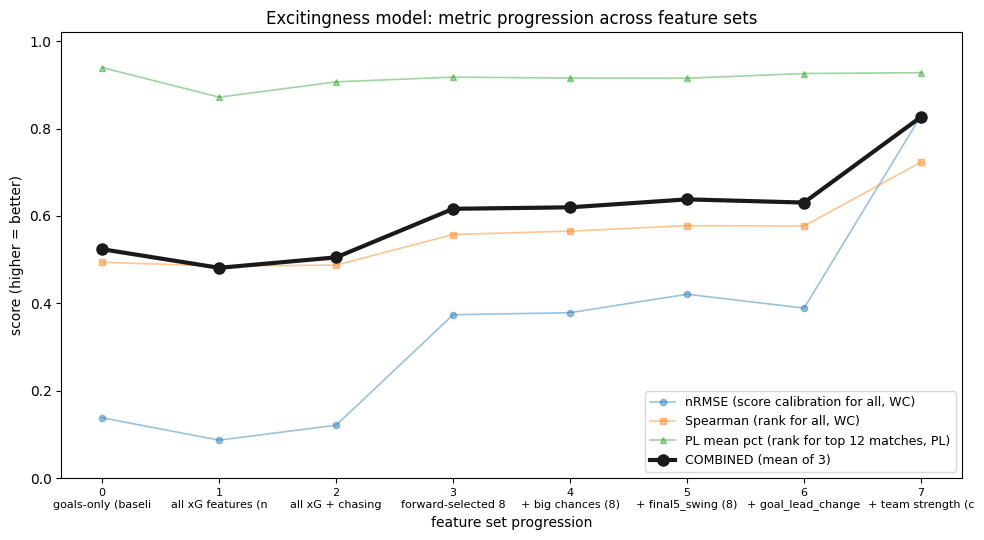

In [22]:
import matplotlib.pyplot as plt

labels = [n.split(".")[0] for n in comparison.feature_set]
xs = range(len(comparison))
fig, ax = plt.subplots(figsize=(10, 5.5))

# three components: subtle
for col, lbl, style in [("nRMSE","nRMSE (score calibration for all, WC)","-o"),
                        ("WC_Spearman","Spearman (rank for all, WC)","-s"),
                        ("PL_meanPct","PL mean pct (rank for top 12 matches, PL)","-^")]:
    ax.plot(xs, comparison[col], style, linewidth=1.2, markersize=4.5,
            alpha=0.45, label=lbl)

# combined: distinct
ax.plot(xs, comparison["COMBINED"], "-o", linewidth=3.0, markersize=8,
        color="#1a1a1a", label="COMBINED (mean of 3)", zorder=5)

ax.set_xticks(list(xs))
ax.set_xticklabels([f"{l}\n{n.split('. ',1)[1][:18]}" for l, n in zip(labels, comparison.feature_set)],
                   fontsize=8)
ax.set_xlabel("feature set progression"); ax.set_ylabel("score (higher = better)")
ax.set_title("Excitingness model: metric progression across feature sets")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "metric_progression.png", dpi=150)
plt.show()